In [1]:
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
from neural_network import NeuralNetwork
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('credit_data.csv')
df.head()

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1


In [3]:
df.loc[df['age'] < 0, 'age'] = 40.92

In [4]:
df['age'].fillna(df['age'].mean(), inplace = True)

C:\Users\hjmar\AppData\Local\Temp\ipykernel_7032\121903411.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(), inplace = True)


In [5]:
df.loc[pd.isnull(df['age'])]

,clientid,income,age,loan,default


In [6]:
df.loc[(df['clientid'] == 29) | (df['clientid'] == 31) | (df['clientid'] == 32)]

,clientid,income,age,loan,default
28,29,59417.805406,40.927689,2082.625938,0
30,31,48528.852796,40.927689,6155.784670,0
31,32,23526.302555,40.927689,2862.010139,0


In [7]:
df.loc[df['clientid'].isin([29, 31, 32])]

,clientid,income,age,loan,default
28,29,59417.805406,40.927689,2082.625938,0
30,31,48528.852796,40.927689,6155.784670,0
31,32,23526.302555,40.927689,2862.010139,0


In [8]:
X_credit = df.iloc[:, 1:4].values

In [9]:
y_credit = df.iloc[:, 4].values

In [10]:
from sklearn.preprocessing import StandardScaler
scaler_credit = StandardScaler()
X_credit = scaler_credit.fit_transform(X_credit)

In [11]:
X_credit_treinamento, X_credit_teste, y_credit_treinamento, y_credit_teste = train_test_split(X_credit, y_credit, test_size = 0.25, random_state = 0)

In [12]:
X_credit_treinamento.shape

(1500, 3)

In [13]:
y_credit_treinamento.shape

(1500,)

In [14]:
nn = NeuralNetwork(input_size=X_credit_treinamento.shape[1], hidden_size=16, lr=0.01)
losses = nn.fit(X_credit_treinamento, y_credit_treinamento, epochs=1000, batch_size=32)

Epoch 0, Loss: 0.5250724001495561
Epoch 50, Loss: 0.821941730364132
Epoch 100, Loss: 1.0497716048296444
Epoch 150, Loss: 1.2151497566067893
Epoch 200, Loss: 1.3580243676834456
Epoch 250, Loss: 1.486349245205587
Epoch 300, Loss: 1.607697299003029
Epoch 350, Loss: 1.7241555373546813
Epoch 400, Loss: 1.836726349214957
Epoch 450, Loss: 1.9432701102692385
Epoch 500, Loss: 2.044794770150299
Epoch 550, Loss: 2.1399653062386665
Epoch 600, Loss: 2.2292351868487152
Epoch 650, Loss: 2.3122962652279346
Epoch 700, Loss: 2.3884230789163214
Epoch 750, Loss: 2.4575970000065306
Epoch 800, Loss: 2.5226601883557476
Epoch 850, Loss: 2.582109581612682
Epoch 900, Loss: 2.636489907354695
Epoch 950, Loss: 2.686010845960764


In [15]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
pred = nn.predict(X_credit_teste)
#y_prob = nn.predict_proba(X_credit_teste)
print(classification_report(y_credit_teste, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       436
           1       1.00      0.97      0.98        64

    accuracy                           1.00       500
   macro avg       1.00      0.98      0.99       500
weighted avg       1.00      1.00      1.00       500



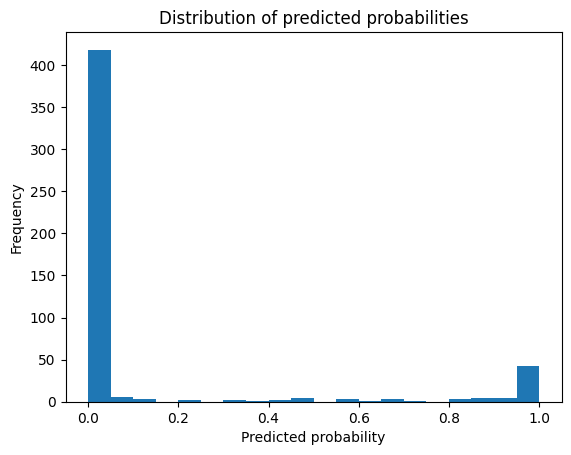

In [16]:
import matplotlib.pyplot as plt

probs = nn.predict_proba(X_credit_teste)

plt.hist(probs, bins=20)
plt.xlabel("Predicted probability")
plt.ylabel("Frequency")
plt.title("Distribution of predicted probabilities")
plt.show()

In [17]:
from sklearn.metrics import accuracy_score, classification_report
accuracy_score(y_credit_teste, pred)

0.996

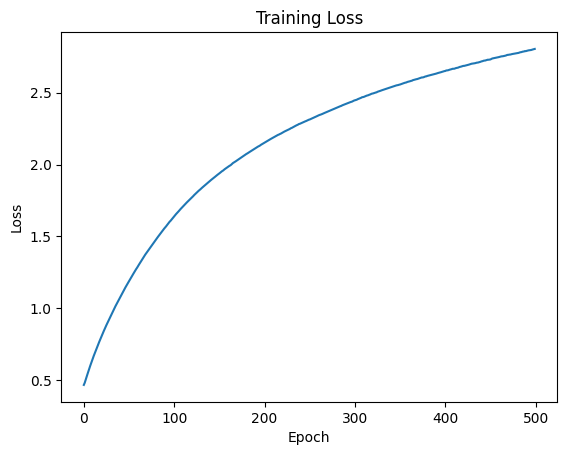

In [17]:
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [18]:
from sklearn.neural_network import MLPClassifier
rede_neural_credit = MLPClassifier(hidden_layer_sizes=(16,),
    activation='relu',
    solver='adam',
    learning_rate_init=0.01,
    max_iter=1000,
    random_state=42)
rede_neural_credit.fit(X_credit_treinamento, y_credit_treinamento)

,hidden_layer_sizes,"(16,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.01
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


In [19]:
previsoes = rede_neural_credit.predict(X_credit_teste)
previsoes

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [20]:
from sklearn.metrics import accuracy_score, classification_report
accuracy_score(y_credit_teste, previsoes)

0.996

In [21]:
print(classification_report(y_credit_teste, previsoes))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       436
           1       0.98      0.98      0.98        64

    accuracy                           1.00       500
   macro avg       0.99      0.99      0.99       500
weighted avg       1.00      1.00      1.00       500

